In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12


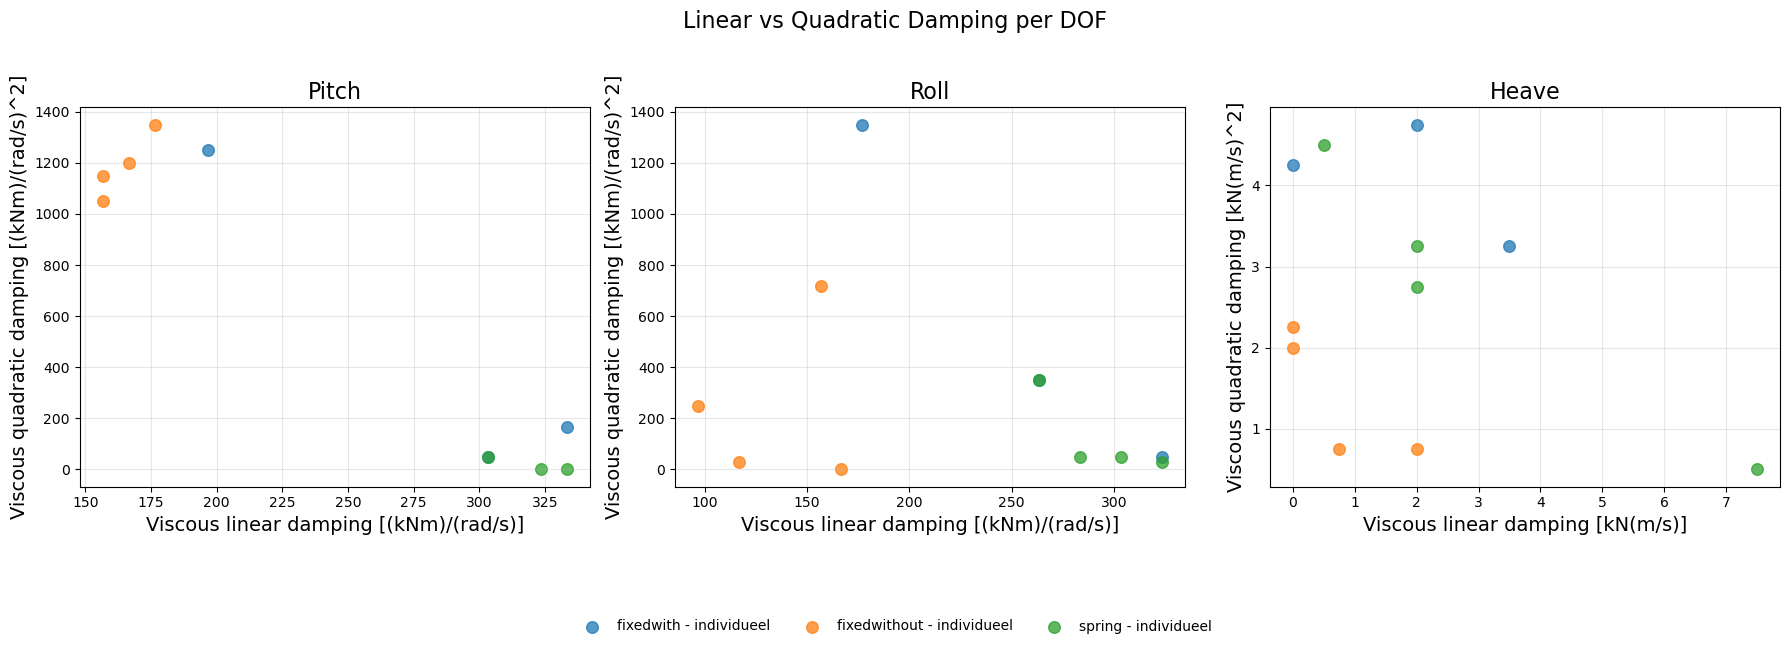

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\linvsquadperdof.png


In [14]:


# =========================
# INPUT
# =========================
excel_path = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\robustness_analysis\robustness_analysis_results.xlsx")
output_path = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\linvsquadperdof.png")

dofs = ["pitch", "roll", "heave"]
detail_sheets = {
    "pitch": "pitch_details",
    "roll": "roll_details",
    "heave": "heave_details",
}

# =========================
# DATA INLADEN
# =========================
summary = pd.read_excel(excel_path, sheet_name="summary")

# vaste kleuren per constructie
constructions = sorted(summary["construction"].dropna().unique())

color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_map = {
    construction: color_cycle[i % len(color_cycle)]
    for i, construction in enumerate(constructions)
}

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

rad_damping_heave = 3.7
rad_damping_rot = 80

for ax, dof in zip(axes, dofs):

    if dof.lower() == "heave":
        rad_damping = rad_damping_heave
        x_left = 0
        y_bottom = 0
        lin_unit = "[kN(m/s)]"
        quad_unit = "[kN(m/s)^2]"
    elif dof.lower() in ["pitch", "roll"]:
        rad_damping = rad_damping_rot
        x_left = 0
        y_bottom = -30
        lin_unit = "[(kNm)/(rad/s)]"
        quad_unit = "[(kNm)/(rad/s)^2]"
    else:
        rad_damping = 0
        x_left = None
        y_bottom = None

    details = pd.read_excel(excel_path, sheet_name=detail_sheets[dof])
    details_dof = details[details["dof"].str.lower() == dof.lower()].copy()
    summary_dof = summary[summary["dof"].str.lower() == dof.lower()].copy()
    

    for construction in constructions:
        color = color_map[construction]

        # individuele gecalibreerde coefficienten
        sub_details = details_dof[details_dof["construction"] == construction]
        if not sub_details.empty:
            ax.scatter(
                sub_details["input_linear_damping"],
                sub_details["input_quadratic_damping"],
                marker="o",
                s=70,
                color=color,
                alpha=0.75,
                label=f"{construction} - individueel"
            )
        ax.set_title(f"{dof.capitalize()}", fontsize = TITLE_SIZE)
        ax.set_xlabel(f"Viscous linear damping {lin_unit}", fontsize=LABEL_SIZE)
        ax.set_ylabel(f"Viscous quadratic damping {quad_unit}", fontsize=LABEL_SIZE)

        # mean en best uit summary
        # sub_summary = summary_dof[summary_dof["construction"] == construction]
        # if not sub_summary.empty:
        #     row = sub_summary.iloc[0]

        #     ax.scatter(
        #         row["mean_linear_damping"],
        #         row["mean_quadratic_damping"],
        #         marker="x",
        #         s=160,
        #         linewidths=3,
        #         color=color,
        #         label=f"{construction} - mean"
        #     )

        #     ax.scatter(
        #         row["best_global_lin"],
        #         row["best_global_quad"],
        #         marker="*",
        #         s=260,
        #         color=color,
        #         edgecolor="black",
        #         linewidth=0.8,
        #         label=f"{construction} - best"
        #     )

    
        
    

    ax.grid(True, alpha=0.3)

# één gezamenlijke legenda, zonder dubbele entries
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08)
)

fig.suptitle("Linear vs Quadratic Damping per DOF", fontsize=16)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot opgeslagen als: {output_path}")

In [15]:
df_out = summary.groupby(["construction", "dof"]).agg(
    RMSE_individual_mean=("mean_recomputed_orig_nmrse_total", "mean"),
    RMSE_mean_coeff=("mean_meancoeff_nmrse_total", "mean"),
    RMSE_best_coeff=("mean_bestglobal_nmrse_total", "mean"),
).reset_index()

# =========================
# totaal gemiddelde rij
# =========================
mean_row = pd.DataFrame({
    "construction": ["All"],
    "dof": ["All"],
    "RMSE_individual_mean": [df_out["RMSE_individual_mean"].mean()],
    "RMSE_mean_coeff": [df_out["RMSE_mean_coeff"].mean()],
    "RMSE_best_coeff": [df_out["RMSE_best_coeff"].mean()],
})

# toevoegen
df_out = pd.concat([df_out, mean_row], ignore_index=True)

df_out

,construction,dof,RMSE_individual_mean,RMSE_mean_coeff,RMSE_best_coeff
0,fixedwith,heave,0.209030,0.262296,0.265406
1,fixedwith,pitch,0.073227,0.146004,0.144593
2,fixedwith,roll,0.123009,0.185677,0.191463
3,fixedwithout,heave,0.141731,0.161110,0.154296
4,fixedwithout,pitch,0.079643,0.095504,0.093807
5,fixedwithout,roll,0.067383,0.140327,0.147326
6,spring,heave,0.141118,0.244945,0.246130
7,spring,pitch,0.041591,0.050764,0.053716
8,spring,roll,0.062646,0.084445,0.088740
9,All,All,0.104375,0.152341,0.153942


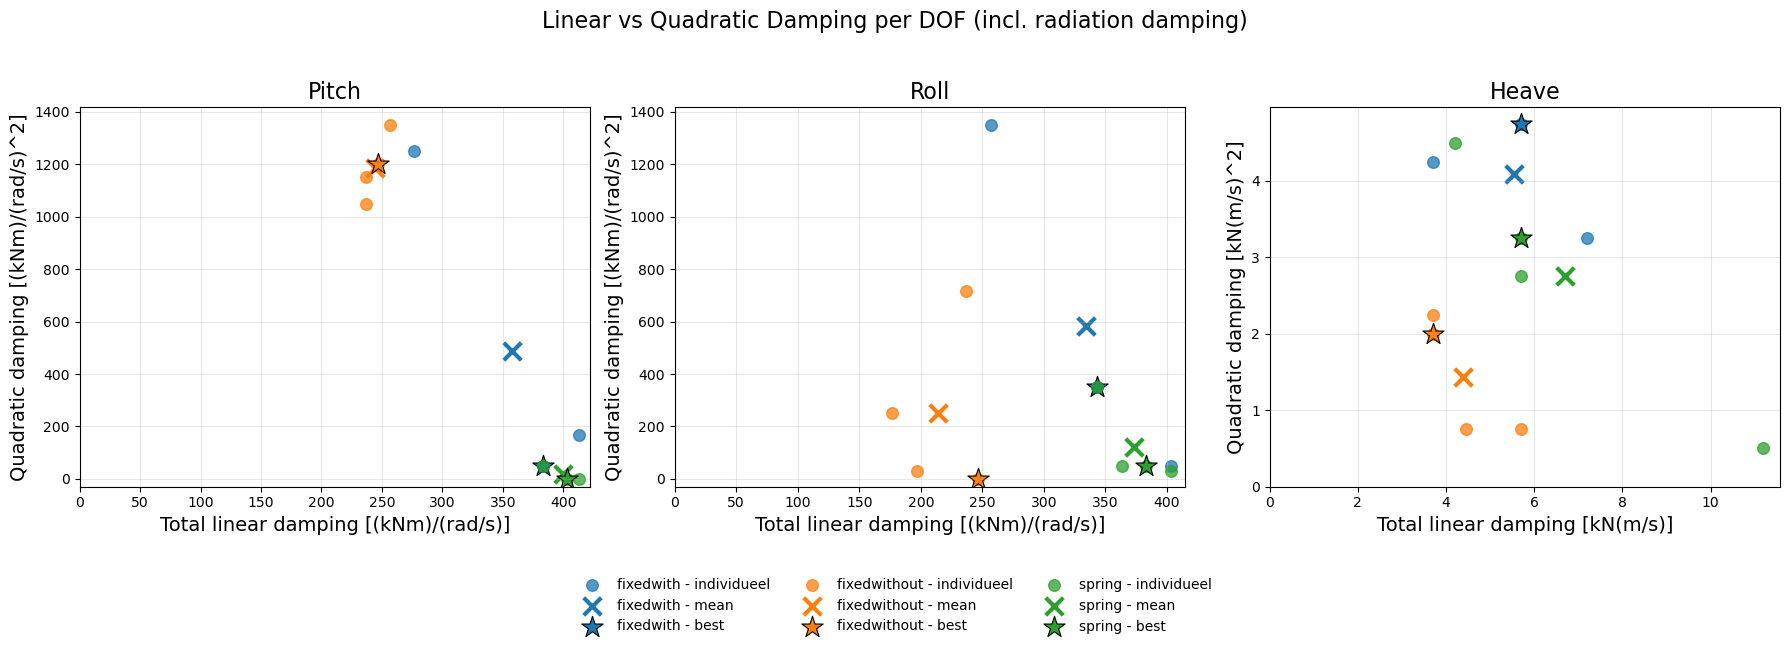

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\linvsquadperdof.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

rad_damping_heave = 3.7
rad_damping_rot = 80

for ax, dof in zip(axes, dofs):

    if dof.lower() == "heave":
        rad_damping = rad_damping_heave
        x_left = 0
        y_bottom = 0
        lin_unit = "[kN(m/s)]"
        quad_unit = "[kN(m/s)^2]"
    elif dof.lower() in ["pitch", "roll"]:
        rad_damping = rad_damping_rot
        x_left = 0
        y_bottom = -30
        lin_unit = "[(kNm)/(rad/s)]"
        quad_unit = "[(kNm)/(rad/s)^2]"
    else:
        rad_damping = 0
        x_left = None
        y_bottom = None

    # =========================
    # data inladen
    # =========================
    details = pd.read_excel(excel_path, sheet_name=detail_sheets[dof])
    details_dof = details[details["dof"].str.lower() == dof.lower()].copy()
    summary_dof = summary[summary["dof"].str.lower() == dof.lower()].copy()

    for construction in constructions:
        color = color_map[construction]

        # =========================
        # individuele coëfficiënten
        # =========================
        sub_details = details_dof[details_dof["construction"] == construction]
        if not sub_details.empty:
            ax.scatter(
                sub_details["input_linear_damping"] + rad_damping,
                sub_details["input_quadratic_damping"],
                marker="o",
                s=70,
                color=color,
                alpha=0.75,
                label=f"{construction} - individueel"
            )

        # =========================
        # mean + best uit summary
        # =========================
        sub_summary = summary_dof[summary_dof["construction"] == construction]
        if not sub_summary.empty:
            row = sub_summary.iloc[0]

            # mean
            ax.scatter(
                row["mean_linear_damping"] + rad_damping,
                row["mean_quadratic_damping"],
                marker="x",
                s=160,
                linewidths=3,
                color=color,
                label=f"{construction} - mean"
            )

            # best
            ax.scatter(
                row["best_global_lin"] + rad_damping,
                row["best_global_quad"],
                marker="*",
                s=260,
                color=color,
                edgecolor="black",
                linewidth=0.8,
                label=f"{construction} - best"
            )

    # =========================
    # styling
    # =========================
    ax.set_title(
        f"{dof.capitalize()}",
        fontsize=TITLE_SIZE
    )
    ax.set_xlabel(f"Total linear damping {lin_unit}", fontsize=LABEL_SIZE)
    ax.set_ylabel(f"Quadratic damping {quad_unit}", fontsize=LABEL_SIZE)
    
    ax.grid(True, alpha=0.3)

    ax.set_xlim(left=x_left)
    ax.set_ylim(bottom=y_bottom)

# =========================
# legenda zonder duplicaten
# =========================
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08)
)

# =========================
# layout + save
# =========================
fig.suptitle("Linear vs Quadratic Damping per DOF (incl. radiation damping)", fontsize=16)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot opgeslagen als: {output_path}")

,dof,n_experiments,dof_global_lin,dof_global_quad,mean_rmse_individueel,mean_rmse_constructie_mean,mean_rmse_best_transfer,mean_rmse_dof_global,verval_pct_tov_individueel,verval_pct_tov_constructie_mean,verval_pct_tov_best_transfer
0,heave,11,1.840278,2.756944,0.159862,0.219191,0.217993,0.321622,101.186732,46.730892,47.537740
1,pitch,10,253.981481,564.351852,0.066303,0.097232,0.097016,0.184348,178.039910,89.595667,90.018575
2,roll,11,227.314815,317.500000,0.080832,0.132374,0.138059,0.258875,220.264876,95.562841,87.509934


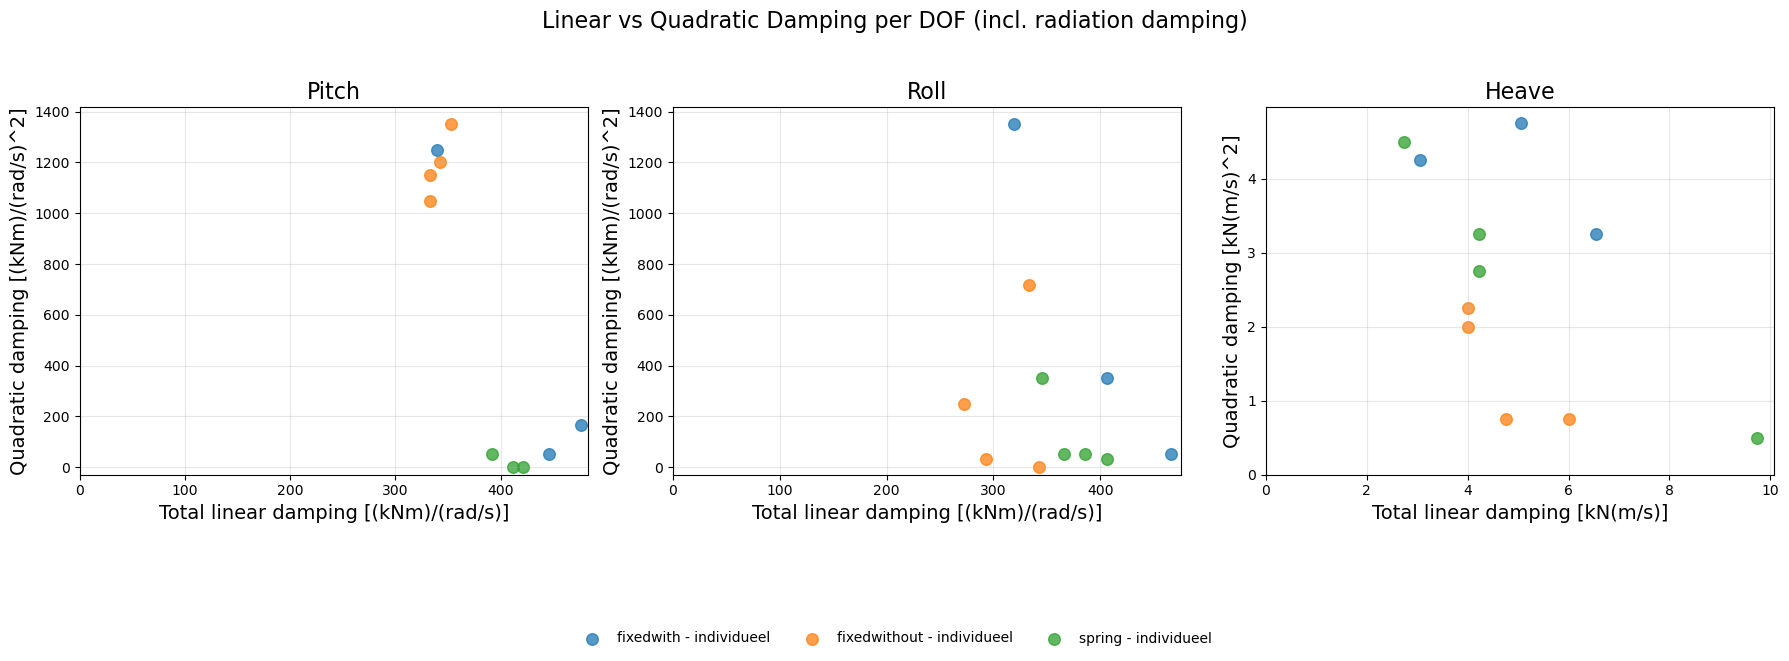

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\linvsquadperdof.png


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# DOF GLOBAL SUMMARY TABEL
# =========================
dof_global = pd.read_excel(excel_path, sheet_name="dof_global_summary")
dof_global.columns = [c.strip() for c in dof_global.columns]

dof_global_table = dof_global[[
    "dof",
    "n_experiments",
    "dof_global_lin",
    "dof_global_quad",
    "mean_rmse_individueel",
    "mean_rmse_constructie_mean",
    "mean_rmse_best_transfer",
    "mean_rmse_dof_global",
    "verval_pct_tov_individueel",
    "verval_pct_tov_constructie_mean",
    "verval_pct_tov_best_transfer",
]].copy()

display(dof_global_table)

# =========================
# RADIATION DAMPING PER CONSTRUCTIE + DOF
# =========================
rad_damping_map = {
    ("fixedwith", "pitch"): 142.78,
    ("fixedwith", "roll"): 142.78,
    ("fixedwith", "heave"): 3.05,

    ("fixedwithout", "pitch"): 176.24,
    ("fixedwithout", "roll"): 176.24,
    ("fixedwithout", "heave"): 4.00,

    ("spring", "pitch"): 88.35,
    ("spring", "roll"): 82.50,
    ("spring", "heave"): 2.23,
}

# voor DOF-global punt: gemiddelde radiation damping over constructies per DOF
rad_damping_dof_mean = {
    dof: sum(
        rad_damping_map[(construction, dof)]
        for construction in constructions
    ) / len(constructions)
    for dof in dofs
}

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

for ax, dof in zip(axes, dofs):

    if dof.lower() == "heave":
        x_left = 0
        y_bottom = 0
        lin_unit = "[kN(m/s)]"
        quad_unit = "[kN(m/s)^2]"
    elif dof.lower() in ["pitch", "roll"]:
        x_left = 0
        y_bottom = -30
        lin_unit = "[(kNm)/(rad/s)]"
        quad_unit = "[(kNm)/(rad/s)^2]"
    else:
        x_left = None
        y_bottom = None
        lin_unit = ""
        quad_unit = ""

    details = pd.read_excel(excel_path, sheet_name=detail_sheets[dof])
    details_dof = details[details["dof"].str.lower() == dof.lower()].copy()
    summary_dof = summary[summary["dof"].str.lower() == dof.lower()].copy()
    dof_global_dof = dof_global[dof_global["dof"].str.lower() == dof.lower()].copy()

    for construction in constructions:
        color = color_map[construction]
        rad_damping = rad_damping_map[(construction, dof.lower())]

        sub_details = details_dof[details_dof["construction"] == construction]
        if not sub_details.empty:
            ax.scatter(
                sub_details["input_linear_damping"] + rad_damping,
                sub_details["input_quadratic_damping"],
                marker="o",
                s=70,
                color=color,
                alpha=0.75,
                label=f"{construction} - individueel"
            )
        # sub_summary = summary_dof[summary_dof["construction"] == construction]
        # if not sub_summary.empty:
        #     row = sub_summary.iloc[0]
        #     ax.scatter(
        #             row["best_global_lin"] + rad_damping,
        #             row["best_global_quad"],
        #             marker="*",
        #             s=260,
        #             color=color,
        #             edgecolor="black",
        #             linewidth=0.8,
        #             label=f"{construction} - best")

        # sub_summary = summary_dof[summary_dof["construction"] == construction]
        # if not sub_summary.empty:
        #     row = sub_summary.iloc[0]

        #     ax.scatter(
        #         row["mean_linear_damping"] + rad_damping,
        #         row["mean_quadratic_damping"],
        #         marker="x",
        #         s=160,
        #         linewidths=3,
        #         color=color,
        #         label=f"{construction} - mean"
        #     )

    # =========================
    # DOF-global best punt
    # =========================
    if not dof_global_dof.empty:
        row_global = dof_global_dof.iloc[0]

        # ax.scatter(
        #     row_global["dof_global_lin"] + rad_damping_dof_mean[dof.lower()],
        #     row_global["dof_global_quad"],
        #     marker="X",
        #     s=220,
        #     color="black",
        #     edgecolor="white",
        #     linewidth=1.0,
        #     label="DOF-global best"
        # )

    ax.set_title(f"{dof.capitalize()}", fontsize=TITLE_SIZE)
    ax.set_xlabel(f"Total linear damping {lin_unit}", fontsize=LABEL_SIZE)
    ax.set_ylabel(f"Quadratic damping {quad_unit}", fontsize=LABEL_SIZE)

    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=x_left)
    ax.set_ylim(bottom=y_bottom)

# =========================
# LEGENDA
# =========================
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.10)
)

fig.suptitle("Linear vs Quadratic Damping per DOF (incl. radiation damping)", fontsize=16)
fig.tight_layout(rect=[0, 0.10, 1, 0.95])

fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot opgeslagen als: {output_path}")

,dof,n_experiments,dof_global_lin,dof_global_quad,mean_rmse_individueel,mean_rmse_constructie_mean,mean_rmse_best_transfer,mean_rmse_dof_global,verval_pct_tov_individueel,verval_pct_tov_constructie_mean,verval_pct_tov_best_transfer
0,heave,11,1.840278,2.756944,0.159862,0.219191,0.217993,0.321622,101.186732,46.730892,47.537740
1,pitch,10,253.981481,564.351852,0.066303,0.097232,0.097016,0.184348,178.039910,89.595667,90.018575
2,roll,11,227.314815,317.500000,0.080832,0.132374,0.138059,0.258875,220.264876,95.562841,87.509934


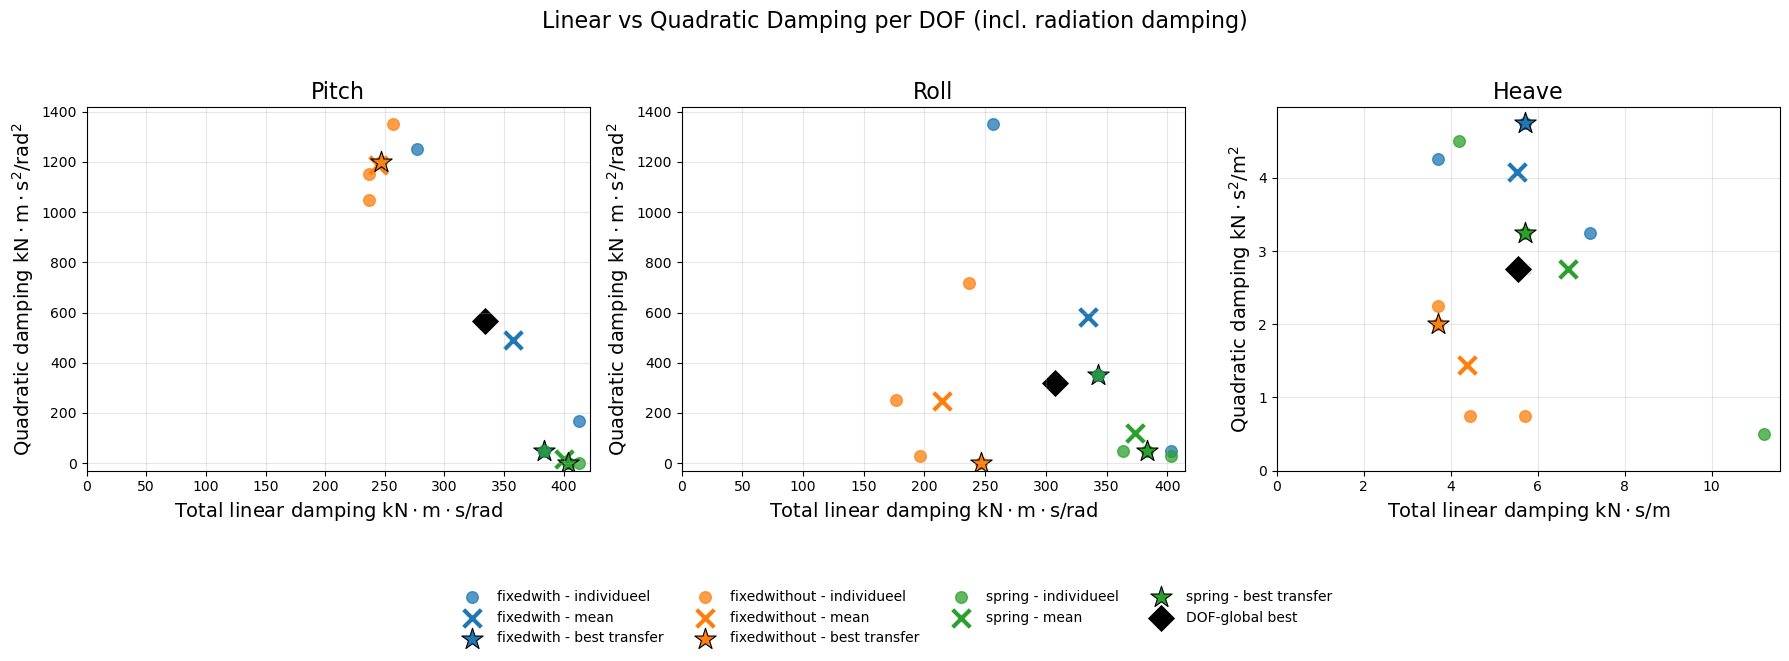

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\linvsquadperdof.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# DOF GLOBAL SUMMARY TABEL
# =========================
dof_global = pd.read_excel(excel_path, sheet_name="dof_global_summary")
dof_global.columns = [c.strip() for c in dof_global.columns]

dof_global_table = dof_global[[
    "dof",
    "n_experiments",
    "dof_global_lin",
    "dof_global_quad",
    "mean_rmse_individueel",
    "mean_rmse_constructie_mean",
    "mean_rmse_best_transfer",
    "mean_rmse_dof_global",
    "verval_pct_tov_individueel",
    "verval_pct_tov_constructie_mean",
    "verval_pct_tov_best_transfer",
]].copy()

display(dof_global_table)


# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

rad_damping_heave = 3.7
rad_damping_rot = 80

for ax, dof in zip(axes, dofs):

    if dof.lower() == "heave":
        rad_damping = rad_damping_heave
        x_left = 0
        y_bottom = 0
        lin_unit = r"$\mathrm{kN \cdot s / m}$"
        quad_unit = r"$\mathrm{kN \cdot s^2 / m^2}$"
    elif dof.lower() in ["pitch", "roll"]:
        rad_damping = rad_damping_rot
        x_left = 0
        y_bottom = -30
        lin_unit = r"$\mathrm{kN \cdot m \cdot s / rad}$"
        quad_unit = r"$\mathrm{kN \cdot m \cdot s^2 / rad^2}$"
    else:
        rad_damping = 0
        x_left = None
        y_bottom = None
        lin_unit = ""
        quad_unit = ""

    details = pd.read_excel(excel_path, sheet_name=detail_sheets[dof])
    details_dof = details[details["dof"].str.lower() == dof.lower()].copy()
    summary_dof = summary[summary["dof"].str.lower() == dof.lower()].copy()
    dof_global_dof = dof_global[dof_global["dof"].str.lower() == dof.lower()].copy()

    for construction in constructions:
        color = color_map[construction]

        sub_details = details_dof[details_dof["construction"] == construction]
        if not sub_details.empty:
            ax.scatter(
                sub_details["input_linear_damping"] + rad_damping,
                sub_details["input_quadratic_damping"],
                marker="o",
                s=70,
                color=color,
                alpha=0.75,
                label=f"{construction} - individueel"
            )

        sub_summary = summary_dof[summary_dof["construction"] == construction]
        if not sub_summary.empty:
            row = sub_summary.iloc[0]

            ax.scatter(
                row["mean_linear_damping"] + rad_damping,
                row["mean_quadratic_damping"],
                marker="x",
                s=160,
                linewidths=3,
                color=color,
                label=f"{construction} - mean"
            )

            ax.scatter(
                row["best_global_lin"] + rad_damping,
                row["best_global_quad"],
                marker="*",
                s=260,
                color=color,
                edgecolor="black",
                linewidth=0.8,
                label=f"{construction} - best transfer"
            )

    # =========================
    # DOF-global best punt
    # =========================
    if not dof_global_dof.empty:
        row_global = dof_global_dof.iloc[0]

        ax.scatter(
            row_global["dof_global_lin"] + rad_damping,
            row_global["dof_global_quad"],
            marker="D",
            s=220,
            color="black",
            edgecolor="white",
            linewidth=1.0,
            label="DOF-global best"
        )

    ax.set_title(f"{dof.capitalize()}", fontsize=TITLE_SIZE)
    ax.set_xlabel(f"Total linear damping {lin_unit}", fontsize=LABEL_SIZE)
    ax.set_ylabel(f"Quadratic damping {quad_unit}", fontsize=LABEL_SIZE)

    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=x_left)
    ax.set_ylim(bottom=y_bottom)

# =========================
# LEGENDA
# =========================
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.10)
)

fig.suptitle("Linear vs Quadratic Damping per DOF (incl. radiation damping)", fontsize=16)
fig.tight_layout(rect=[0, 0.10, 1, 0.95])

fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Plot opgeslagen als: {output_path}")